<a href="https://colab.research.google.com/github/EricFlores1808/MINERIA_EF_LS_1/blob/luis_desarrollo/SocialMediaImpact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El primer paso para trabajar es establecer el entorno de trabajo con las librerías pandas, numpy, seaborn, matplotlib y category_encoders.

In [ ]:
pip install category_encoders

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

El objetivo es transformar el dataset crudo "Teen_Mental_Health_Dataset.csv" en una estructura de datos "DataFrame" que nos permita manipular variables complejas de salud mental. Este paso es el punto de partida para la etapa de Comprensión de los Datos.

In [ ]:
df = pd.read_csv("/content/Teen_Mental_Health_Dataset.csv")

In [ ]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


Para otorgar contexto al análisis, realizamos un mapeo de datos. No todas las variables se tratan igual: la 'Edad' es numérica, pero el 'Nivel de Estrés' es categórico. Identificar esto evita errores metodológicos al momento de aplicar funciones estadísticas, asegurando que la naturaleza de la información sea respetada.

In [ ]:
print("--------------- Informacion del Dataset ---------------")
df.info()

--------------- Informacion del Dataset ---------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: floa

Un análisis es tan bueno como la calidad de sus datos. Realizamos una auditoría técnica buscando valores nulos o duplicados. La ausencia de estos problemas garantiza que las conclusiones sobre ansiedad y uso de redes sociales no estén sesgadas por errores de registro o datos faltantes, otorgando validez al trabajo.

In [ ]:
print("------ Conteo de nulos ------")
print(df.isna().sum())
print("-----------------------------")
print(f"Registros duplicados encontrados: {df.duplicated().sum()}")

------ Conteo de nulos ------
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64
-----------------------------
Registros duplicados encontrados: 0


Tras la inspección, confirmamos un dataset con 0 valores nulos y sin duplicados. Esto nos permite avanzar con total confianza hacia la exploración estadística sin necesidad de técnicas de imputación de datos.

In [ ]:
cant_cat_plat = df['platform_usage'].value_counts()
print(cant_cat_plat)
print("-----------------------------")
cant_cat_si = df['social_interaction_level'].value_counts()
print(cant_cat_si)
print("-----------------------------")
cant_cat_gen = df['gender'].value_counts()
print(cant_cat_gen)

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64
-----------------------------
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64
-----------------------------
gender
male      615
female    585
Name: count, dtype: int64


Buscamos una visión general de la población estudiada. El uso de .describe() nos permite observar la media, la desviación estándar y los valores máximos de variables críticas. Aplicamos para asegurar que la visualización técnica sea completa y profesional.

In [ ]:
df.describe().round()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.0,1200.0,1200.0,1200.0,1200.0,1200.0,1200.0,1200.0,1200.0,1200.0
mean,16.0,5.0,6.0,2.0,3.0,1.0,5.0,6.0,6.0,0.0
std,2.0,2.0,1.0,1.0,1.0,1.0,3.0,3.0,3.0,0.0
min,13.0,1.0,4.0,0.0,2.0,0.0,1.0,1.0,1.0,0.0
25%,14.0,3.0,5.0,1.0,2.0,0.0,3.0,3.0,3.0,0.0
50%,16.0,4.0,6.0,2.0,3.0,1.0,5.0,6.0,6.0,0.0
75%,18.0,6.0,8.0,2.0,3.0,2.0,8.0,8.0,8.0,0.0
max,19.0,8.0,9.0,3.0,4.0,2.0,10.0,10.0,10.0,1.0


Observamos que el promedio de horas en redes sociales ronda las 5 horas, lo cual ya nos da un indicio de alta exposición. El nivel de estrés promedio se sitúa en 5, lo que sugiere que estamos ante una muestra con niveles de tensión emocional considerables que requieren un análisis profundo de sus causas.



---



Construimos 3 graficos para entender quiénes son los jóvenes de la muestra. Analizamos el género, la cantidad de personas que usa cada red social y el rango de edad de los adolecentes. Esto nos ayuda a segmentar si el impacto en la salud mental podría estar condicionado por la preferencia de una red social específica (como TikTok, Instagram u ambas).

/tmp/ipykernel_17036/3438892084.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=df, x='gender', palette='pastel', ax=ax[0])
/tmp/ipykernel_17036/3438892084.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=df, x='platform_usage', palette='viridis', ax=ax[1])
/tmp/ipykernel_17036/3438892084.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(df['age'], kde=True, color='skyblue', palette='pastel', ax=ax[2])


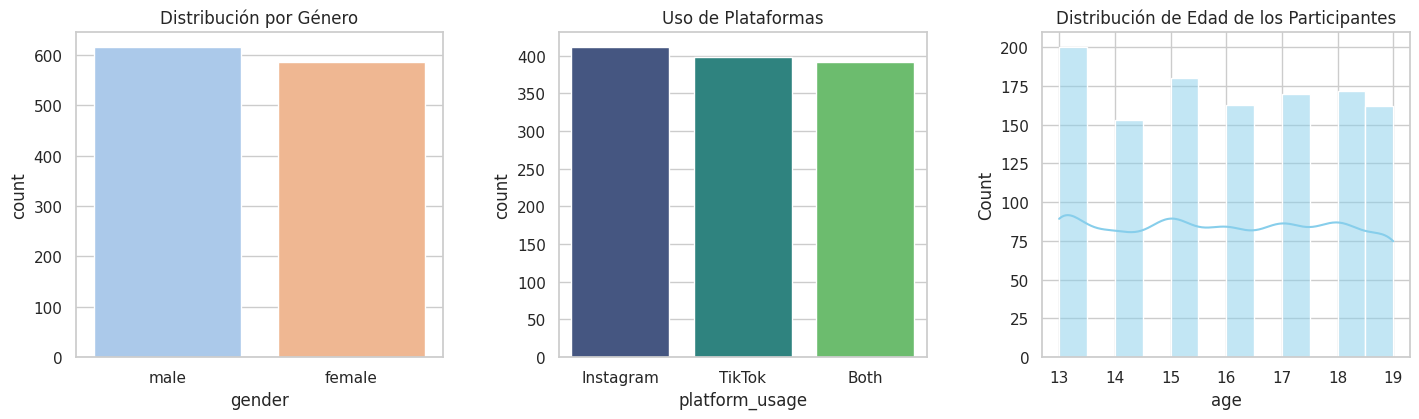

In [ ]:
# Configuración visual
sb.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Distribución de Género y Plataforma (Mezclando tus conteos con visualización)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sb.countplot(data=df, x='gender', palette='pastel', ax=ax[0])
ax[0].set_title('Distribución por Género')

sb.countplot(data=df, x='platform_usage', palette='viridis', ax=ax[1])
ax[1].set_title('Uso de Plataformas')

sb.histplot(df['age'], kde=True, color='skyblue', palette='pastel', ax=ax[2])
ax[2].set_title('Distribución de Edad de los Participantes')

plt.tight_layout(pad=3.0)
plt.show()

El análisis visual revela que la muestra está balanceada equitativamente entre géneros y que no hay una plataforma que domine sobre otra, lo que hace que nuestro análisis de impacto sea justo. La edad se concentra en la adolescencia media, etapa crítica para el desarrollo de trastornos de ansiedad vinculados a el apego a las pantallas.

Para que el conjunto de datos sea admisible en modelos de regresión o clasificación futuros, aplicamos un proceso de Encoding. Las variables cualitativas como 'Plataforma' o 'Nivel de Interacción' no pueden ser procesadas directamente por algoritmos matemáticos. Utilizamos la técnica de One-Hot Encoding para transformar cada categoría en una columna independiente de tipo binario (0 y 1). Esto evita que el modelo asuma un orden de importancia falso entre las plataformas y permite cuantificar el impacto individual de cada una en la salud mental.

In [ ]:
# @title Encoding de se interaccion social
ohe = OneHotEncoder(sparse_output=False)
social_encoded = ohe.fit_transform(df[['social_interaction_level']])

social_encoded_df = pd.DataFrame(
    social_encoded,
    columns=ohe.get_feature_names_out(['social_interaction_level']),
    index=df.index
)

print(social_encoded_df.head(10))

   social_interaction_level_high  social_interaction_level_low  \
0                            0.0                           1.0   
1                            1.0                           0.0   
2                            1.0                           0.0   
3                            0.0                           0.0   
4                            0.0                           0.0   
5                            1.0                           0.0   
6                            0.0                           1.0   
7                            0.0                           1.0   
8                            1.0                           0.0   
9                            1.0                           0.0   

   social_interaction_level_medium  
0                              0.0  
1                              0.0  
2                              0.0  
3                              1.0  
4                              1.0  
5                              0.0  
6             

In [ ]:
ohe = OneHotEncoder(sparse_output=False)
plat_usag = ohe.fit_transform(df[['platform_usage']])

platf_usag_df = pd.DataFrame(
    plat_usag,
    columns=ohe.get_feature_names_out(['platform_usage']),
    index=df.index
)

print(platf_usag_df.head(10))

   platform_usage_Both  platform_usage_Instagram  platform_usage_TikTok
0                  0.0                       1.0                    0.0
1                  0.0                       0.0                    1.0
2                  0.0                       1.0                    0.0
3                  0.0                       0.0                    1.0
4                  1.0                       0.0                    0.0
5                  1.0                       0.0                    0.0
6                  0.0                       1.0                    0.0
7                  1.0                       0.0                    0.0
8                  0.0                       0.0                    1.0
9                  0.0                       0.0                    1.0


In [ ]:
be = ce.BinaryEncoder(cols=['gender'])
gen_bin_df = be.fit_transform(df['gender'])


df_final = pd.concat([df.drop(columns=[ 'gender', 'age', 'social_interaction_level', 'platform_usage']), gen_bin_df, social_encoded_df, platf_usag_df], axis=1)


print(df_final.head())
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")

   daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
0                       7.9          7.4                       2.9   
1                       1.9          8.0                       2.9   
2                       1.3          7.6                       0.5   
3                       7.4          6.9                       1.6   
4                       4.7          4.9                       3.0   

   academic_performance  physical_activity  stress_level  anxiety_level  \
0                  3.01                1.5             2              2   
1                  3.22                0.8             8              1   
2                  3.92                0.0             2              4   
3                  3.48                0.8             1              7   
4                  2.37                1.4             3              5   

   addiction_level  depression_label  gender_0  gender_1  \
0                1                 0         0         1   
1       

In [ ]:
df_final.head(100)

,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_0,gender_1,social_interaction_level_high,social_interaction_level_low,social_interaction_level_medium,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok
0,7.9,7.4,2.9,3.01,1.5,2,2,1,0,0,1,0.0,1.0,0.0,0.0,1.0,0.0
1,1.9,8.0,2.9,3.22,0.8,8,1,10,0,1,0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,1.0,0.0,0.0,0.0,1.0,0.0
3,7.4,6.9,1.6,3.48,0.8,1,7,9,0,0,1,0.0,0.0,1.0,0.0,0.0,1.0
4,4.7,4.9,3.0,2.37,1.4,3,5,2,0,1,0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.8,6.4,2.4,2.16,1.9,3,6,9,0,1,0,0.0,0.0,1.0,0.0,1.0,0.0
96,3.1,5.4,1.9,3.66,0.4,7,4,2,0,0,1,0.0,1.0,0.0,0.0,0.0,1.0
97,3.5,5.2,2.5,2.57,1.1,1,6,3,0,1,0,1.0,0.0,0.0,0.0,0.0,1.0
98,7.4,6.4,2.2,3.51,1.0,4,5,4,0,0,1,1.0,0.0,0.0,0.0,0.0,1.0


Como resultado del Encoding, el dataset ha pasado de tener columnas de texto a una matriz numérica expandida. Ahora, por ejemplo, contamos con columnas específicas como gender_x/y , platform_usage_rrss y social_interaction_level_x/y/z. Esto nos permitirá, en la siguiente fase, realizar correlaciones mucho más granulares; por ejemplo, determinar si pertenecer al grupo de 'Interacción Social Baja' tiene un peso estadístico mayor en el nivel de ansiedad que el uso de una plataforma específica.

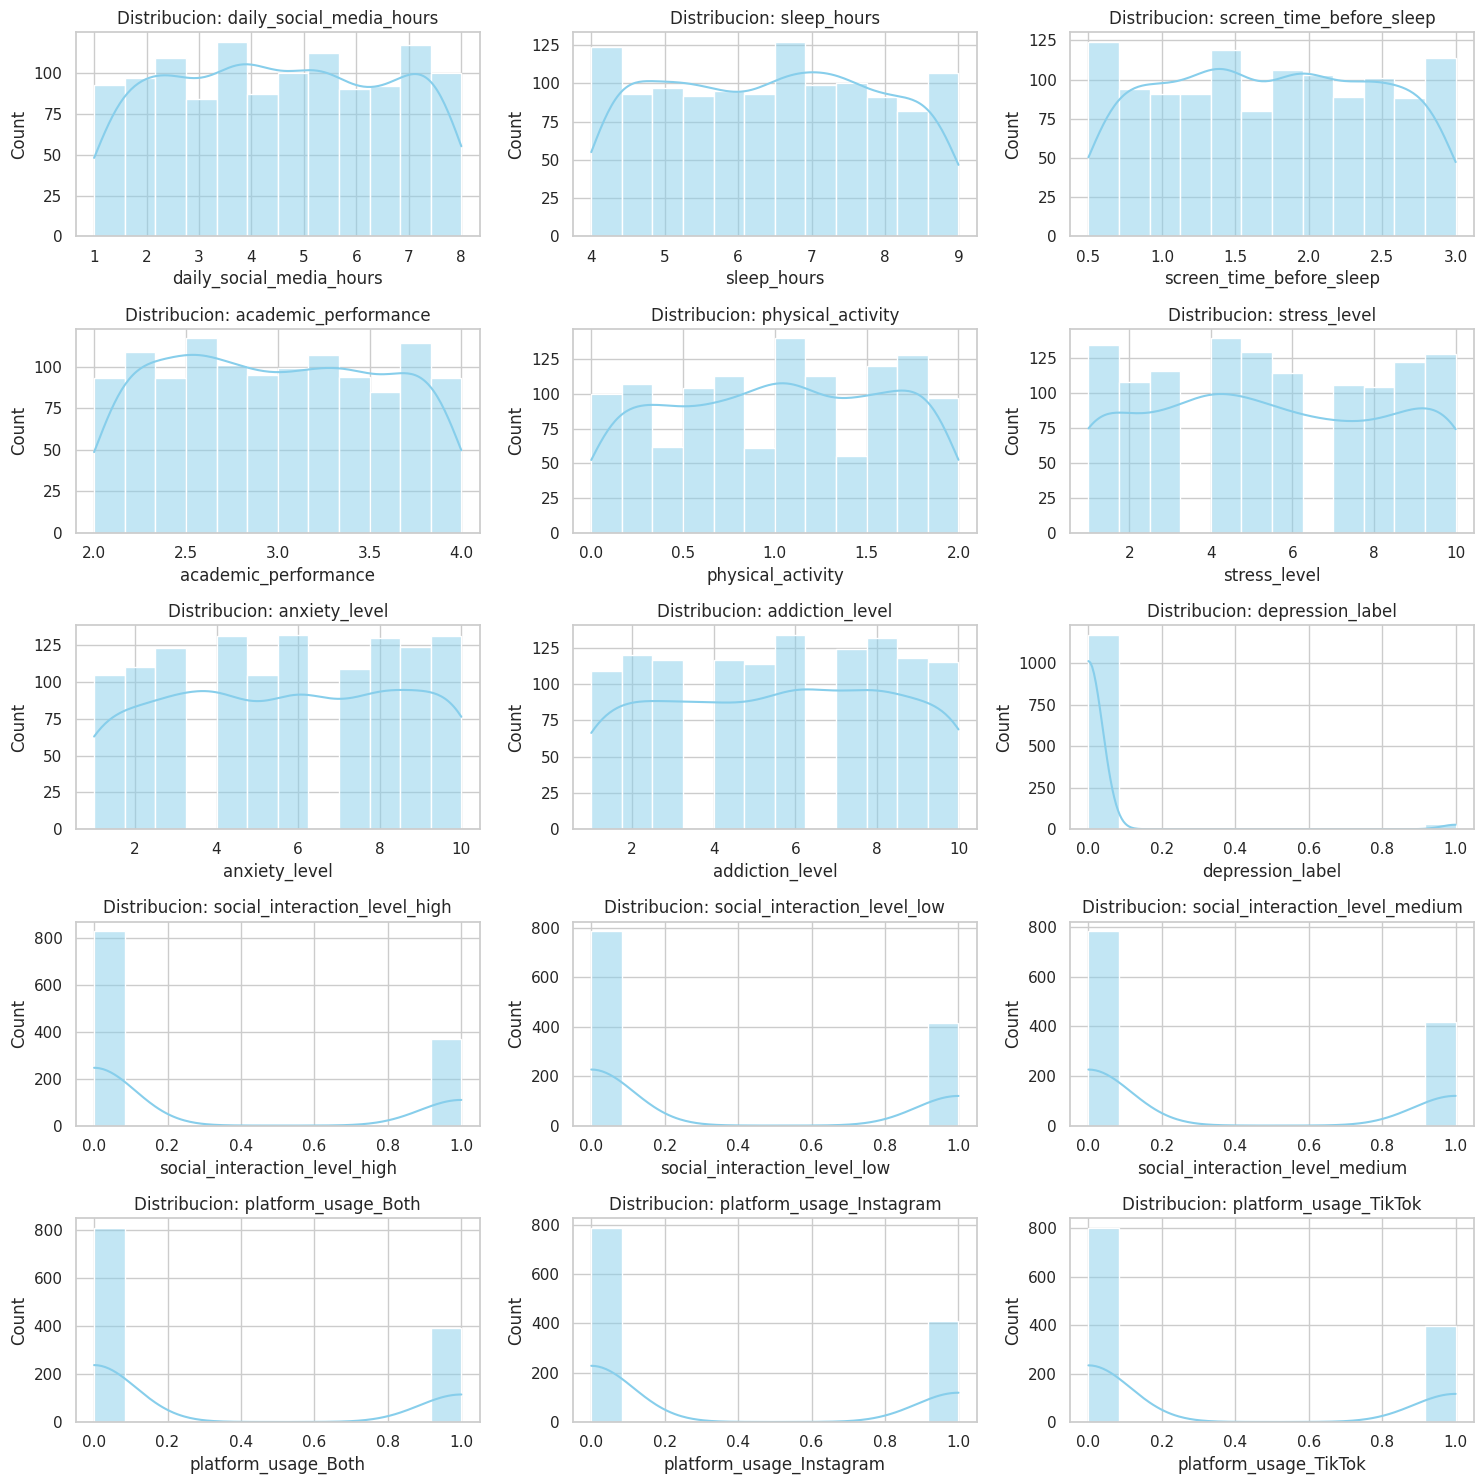

In [ ]:
cols_numericas = [
    'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label',
       'social_interaction_level_high', 'social_interaction_level_low',
       'social_interaction_level_medium', 'platform_usage_Both',
       'platform_usage_Instagram', 'platform_usage_TikTok'
]

# Configuracion de graficos
plt.figure(figsize=(15, 15))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(5, 3, i)
    sb.histplot(df_final[col], kde=True, color='skyblue')
    plt.title(f'Distribucion: {col}')

plt.tight_layout()
plt.show()